<a href="https://colab.research.google.com/github/CristianoCoelhoSilva/Python/blob/master/Script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import seaborn
import matplotlib
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso#Loading the dataset
import matplotlib.pyplot as plt
import statsmodels.api as sm
%matplotlib inline

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [3]:
#Arquivo completo
df = pd.read_csv(r"https://raw.githubusercontent.com/CristianoCoelhoSilva/Python/master/Python/covid.csv")

#Removendo as colunas
df.drop(["GENERO","RACA","MES",'ESCOLARIDADE','ESTABELECIMENTO'], axis="columns", inplace=True)
df.drop(["ENTUBADO"], axis="columns", inplace=True)

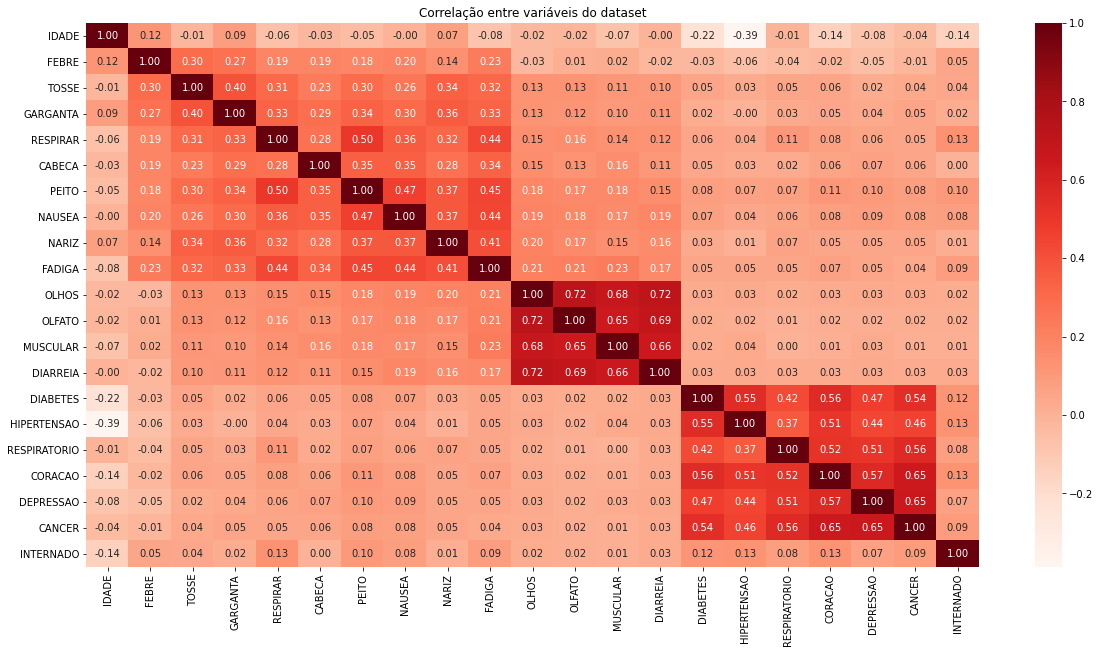

In [4]:
a4_dims = (20, 10)
fig, ax = plt.subplots(figsize=a4_dims)

seaborn.heatmap(df.corr(),
            annot = True,
            fmt = '.2f',
            cmap='Reds')
plt.title('Correlação entre variáveis do dataset')
plt.show()

In [5]:
##Fazendo o holdout

X = df.drop(['INTERNADO'], axis = "columns")
y = df.INTERNADO

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 13)

# Cria nosso pipeline para pré-processamento com imputação, dummização e normalização
encoder_imputer_scaled_transformer = make_column_transformer(
    (make_pipeline(
        (KNNImputer(n_neighbors = 3)),
        (StandardScaler())
    ) , make_column_selector(dtype_include = np.number)),
    (make_pipeline(
        SimpleImputer(strategy = 'most_frequent'),
        OneHotEncoder(handle_unknown = 'ignore'),
    ), make_column_selector(dtype_exclude = np.number)),
    remainder = 'passthrough'
)

encoder_imputer_scaled_transformer.fit(X_train)

X_train_processed = encoder_imputer_scaled_transformer.transform(X_train)
X_test_processed = encoder_imputer_scaled_transformer.transform(X_test)

model  = RandomForestClassifier()
model.fit(X_train_processed, y_train)# Mostrando importância de cada feature
model.feature_importances_

array([0.39034254, 0.03170704, 0.0384365 , 0.03759555, 0.03671627,
       0.03810073, 0.03096328, 0.03295619, 0.03431645, 0.032211  ,
       0.03288434, 0.03412955, 0.0397274 , 0.04039851, 0.02813882,
       0.03275682, 0.02911106, 0.02522932, 0.02288366, 0.01139496])

Text(0.5, 1.0, 'Importância de cada feature')

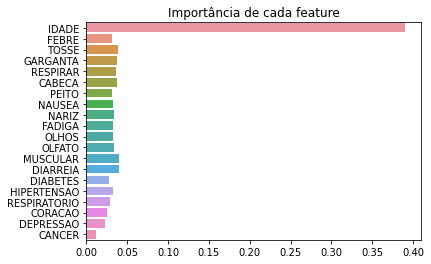

In [6]:
importances = pd.Series(data=model.feature_importances_, index=X.columns)
seaborn.barplot(x=importances, y=importances.index, orient='h').set_title('Importância de cada feature')

In [38]:
#apply SelectKBest class to extract top 10 best features
bestfeatures = SelectKBest(score_func=chi2, k=10)
fit = bestfeatures.fit(X,y)

dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)
#concat two dataframes for better visualization 
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Specs','Score']  #naming the dataframe columns
print(featureScores.nlargest(10,'Score'))  #print 10 best features

          Specs        Score
0         IDADE  4209.911966
13     DIARREIA    70.771055
15  HIPERTENSAO    54.672826
3      GARGANTA    51.416049
8         NARIZ    49.955685
4      RESPIRAR    47.293066
6         PEITO    46.199088
14     DIABETES    43.325900
7        NAUSEA    42.056019
17      CORACAO    39.585077


In [39]:
reg = LassoCV()
reg.fit(X, y)
print("Best alpha using built-in LassoCV: %f" % reg.alpha_)
print("Best score using built-in LassoCV: %f" %reg.score(X,y))
coef = pd.Series(reg.coef_, index = X.columns)

Best alpha using built-in LassoCV: 0.006613
Best score using built-in LassoCV: 0.039316


Text(0.5, 1.0, 'Feature importance using Lasso Model')

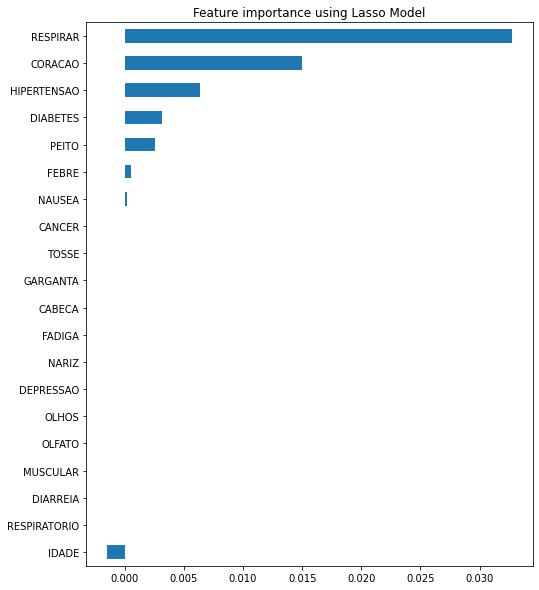

In [40]:
imp_coef = coef.sort_values()
import matplotlib
matplotlib.rcParams['figure.figsize'] = (8.0, 10.0)
imp_coef.plot(kind = "barh")
plt.title("Feature importance using Lasso Model")

## Cross Validation

In [7]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.externals.six import StringIO  
from IPython.display import Image  
from sklearn.tree import export_graphviz
import pydotplus

/usr/local/lib/python3.6/dist-packages/sklearn/externals/six.py:31: FutureWarning: The module is deprecated in version 0.21 and will be removed in version 0.23 since we've dropped support for Python 2.7. Please rely on the official version of six (https://pypi.org/project/six/).
  "(https://pypi.org/project/six/).", FutureWarning)


In [8]:
X_processed = encoder_imputer_scaled_transformer.fit_transform(X)

In [47]:
import seaborn
import matplotlib.pyplot as plt

results_cross_validation = []
for k in range(3, 51):
  for time in range(30):
    kf = KFold(n_splits=k, shuffle=True).split(X_processed)
    scores = cross_val_score(knn, X_processed, y, cv=kf, scoring='accuracy')
    results_cross_validation = results_cross_validation + [[k, time, np.mean(scores)]]

KeyboardInterrupt: ignored

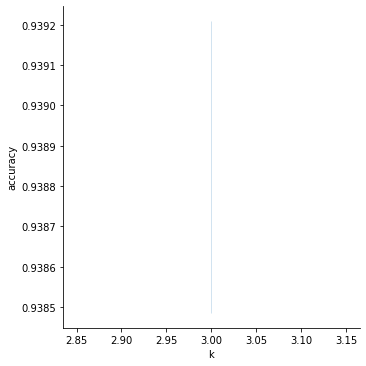

In [48]:
df = pd.DataFrame(results_cross_validation,columns=['k','time_id', 'accuracy'])

seaborn.relplot(data = df,
                x = 'k',
                y = 'accuracy',
                kind = 'line')
plt.show()

In [52]:
results = pd.DataFrame(columns=['n_neighbors', 'accuracy'])

for n_neighbors in range(1, 31):
  knn = KNeighborsClassifier(n_neighbors = n_neighbors)
  scores = cross_val_score(knn, X_train_processed, y_train, cv=9, scoring='accuracy')
  results = results.append({'n_neighbors' : n_neighbors,
                  'accuracy' : np.mean(scores)}, ignore_index = True)

O k que maximiza a acurácia no conjunto de treinamento é: 14


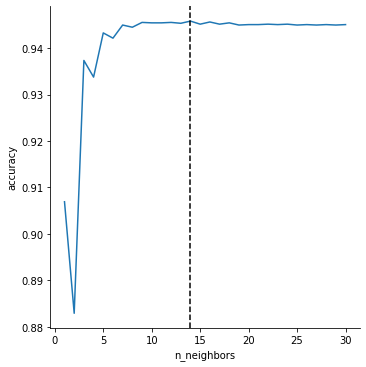

In [51]:
import seaborn
import matplotlib.pyplot as plt

melhor_k = int(results[results.accuracy == results.accuracy.max()]['n_neighbors'].values[0])

seaborn.relplot(data = results,
                x = 'n_neighbors',
                y = 'accuracy',
                kind = 'line')
plt.axvline(x=melhor_k, color="black", linestyle= "--")

print("O k que maximiza a acurácia no conjunto de treinamento é: {}".format(melhor_k))

In [12]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("preprocessamento", encoder_imputer_scaled_transformer),
    ("knn", KNeighborsClassifier())
])

grid_valores = {"knn__n_neighbors": range(1, 31)}

classificador = GridSearchCV(estimator = pipeline, 
                              param_grid = grid_valores,
                              cv = 10, 
                              scoring = "accuracy", 
                              refit = True)

classificador

GridSearchCV(cv=10, error_score=nan,
             estimator=Pipeline(memory=None,
                                steps=[('preprocessamento',
                                        ColumnTransformer(n_jobs=None,
                                                          remainder='passthrough',
                                                          sparse_threshold=0.3,
                                                          transformer_weights=None,
                                                          transformers=[('pipeline-1',
                                                                         Pipeline(memory=None,
                                                                                  steps=[('knnimputer',
                                                                                          KNNImputer(add_indicator=False,
                                                                                                     copy=True,
                    

In [13]:
classificador.fit(X_train, y_train)

/usr/local/lib/python3.6/dist-packages/sklearn/model_selection/_split.py:667: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  % (min_groups, self.n_splits)), UserWarning)


GridSearchCV(cv=10, error_score=nan,
             estimator=Pipeline(memory=None,
                                steps=[('preprocessamento',
                                        ColumnTransformer(n_jobs=None,
                                                          remainder='passthrough',
                                                          sparse_threshold=0.3,
                                                          transformer_weights=None,
                                                          transformers=[('pipeline-1',
                                                                         Pipeline(memory=None,
                                                                                  steps=[('knnimputer',
                                                                                          KNNImputer(add_indicator=False,
                                                                                                     copy=True,
                    

In [14]:
print("Melhor parâmetro do modelo knn: ")
print(classificador.best_params_)

print("Desempenho médio no fold de teste: ")
print(np.mean(classificador.cv_results_['mean_test_score']))

Melhor parâmetro do modelo knn: 
{'knn__n_neighbors': 13}
Desempenho médio no fold de teste: 
0.9408620558310437


In [15]:
y_pred = classificador.predict(X_test)

accuracy_score(y_pred = y_pred,
               y_true = y_test)

0.9483970136144049

## Script

## Desion tree

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.externals.six import StringIO  
from IPython.display import Image  
from sklearn.tree import export_graphviz
import pydotplus

confusion_matrix(y_test, y_pred)

dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,  
                filled=True, rounded=True,
                special_characters=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
Image(graph.create_png())